In [14]:
import numpy as np
from numba import cuda
import cv2
import matplotlib.pyplot as plt
from google.colab import files
import os
import math
from numba import cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1 # resuelve bug de versiones

### **Ejercicio 1**

Saving vignette_debug.jpg to vignette_debug (1).jpg
User uploaded file "vignette_debug (1).jpg"


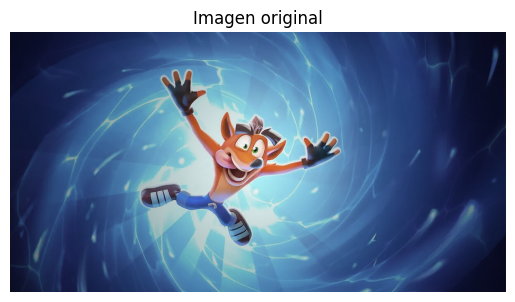

In [15]:
# Funcion apra cargar una imagen
def upload_image():
    uploaded = files.upload()
    for filename in uploaded.keys():
        print(f'User uploaded file "{filename}"')
        return filename
    return None

# Llamar la función de carga
image_path = upload_image()

if image_path:
    # Leer la imagen usando OpneCV
    img_color = cv2.imread(image_path)
    if img_color is None:
        print(f"Error: Could not read image from {image_path}")
    else:
        # OpenCV lee la imagen como BGR, la convertimos en RGB para mostrara con Matplotlib
        img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        plt.title("Imagen original")
        plt.axis('off')
        plt.show()
else:
    print("No se subio ninguna imagen")

Ahora, definimos el kernel de CUDA para inverti el color. Este kernel se ejecutara en la GPU, con cada hilo procesando un canal de pixel

In [16]:
@cuda.jit
def invert_colors_kernel(input_image, output_image):
    # Calcular el indice linal global para el hilo actual
    idx = cuda.grid(1)

    # Verificar si el indice esta dentor de los limites de la imagen
    if idx < input_image.size:
        # Calcular el color invertido: 255 - valor_original
        output_image[idx] = 255 - input_image[idx]


Finalmente, prepararemos los datos de la imagen, transferirlo a la GPU, lanzar el kernel, devolver el resultado de la imagen y mostrar la imagen invertida.

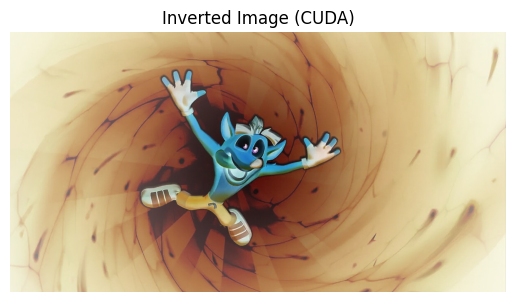

In [17]:
if 'img_color' in locals() and img_color is not None:
    # Aplanar la imagen a una arreglo ID para un procesaminento más sencillo por el kernel
    img_flat = img_color.flatten()

    # Asignar memoria a la GPU para la enrada y salida de iamgenes
    d_input_image = cuda.to_device(img_flat)
    d_output_image = cuda.device_array_like(d_input_image)

    # Definir el número de hilos por bloque y bloques por grilla
    threads_per_block = 256
    blocks_per_grid = (img_flat.size + (threads_per_block - 1)) // threads_per_block

    # Lanzar el kernel CUDA
    invert_colors_kernel[blocks_per_grid, threads_per_block](d_input_image, d_output_image)

    # Transferir la imagen invertida de la GPU a la CPU
    inverted_flat = d_output_image.copy_to_host()

    # Redimensionar el arreglo aplanado devuelta las dimesiones roginales de la imagen
    inverted_img_bgr = inverted_flat.reshape(img_color.shape)

    # Convertir BGR a RGB para mostrarlo con matplotlib
    inverted_img_rgb = cv2.cvtColor(inverted_img_bgr, cv2.COLOR_BGR2RGB)

    # Mostar la imagen ivertida
    plt.imshow(inverted_img_rgb)
    plt.title("Inverted Image (CUDA)")
    plt.axis('off')
    plt.show()
else:
    print("Please upload an image using the cell above first.")

#### **Análisis y Conclusión del Ejercicio 1: Invertir Colores**

**Análisis:**
El primer ejercicio implementa una función de inversión de colores utilizando un kernel CUDA (`invert_colors_kernel`). Este kernel está diseñado para procesar la imagen aplanada en un array 1D, donde cada hilo CUDA es responsable de invertir el color de un único componente de píxel (R, G o B). La operación es sencilla: `output_image[idx] = 255 - input_image[idx]`, lo que invierte el valor de intensidad de cada canal. La imagen se carga, se convierte a RGB para visualización, se aplana y se transfiere a la GPU para el procesamiento paralelo.

**Conclusión:**
Esta implementación demuestra eficazmente la capacidad de CUDA para realizar operaciones elementales de procesamiento de imágenes de manera masivamente paralela. La inversión de colores es una tarea 'embarrassingly parallel', donde cada píxel puede ser procesado independientemente de los demás. Esto resulta en una aceleración significativa en comparación con una implementación secuencial en CPU, especialmente para imágenes de alta resolución. La configuración de `threads_per_block` y `blocks_per_grid` asegura que todos los elementos de la imagen aplanada sean cubiertos por los hilos de la GPU, optimizando el uso de los recursos computacionales del dispositivo.

### **Ejercicio 2**

Primero, defniremos el kernel de CUDA para el average blurring. Este kernel tomará la imagen de entrada, la salida de la imagen, las dimensiones de la imagen y el tamaño del kernel como pararmetros. Cada hilo será responsable de calcular el valor blur de cada canal de pixel po rel promedio de sus vecinos.

In [18]:
@cuda.jit
def blur_image_kernel(input_image, output_image, height, width, channels, kernel_size):

    # Calcular el índice lineal global para el subproceso actual.
    idx = cuda.grid(1)

    # Comprueba si el índice está dentro de los límites de los datos de la imagen.
    if idx >= input_image.size:
        return

    # Descomponer el índice lineal en índices de altura (fila), anchura (columna) y canal.
    h = idx // (width * channels)
    w = (idx // channels) % width
    c = idx % channels

    #  Calcular el radio del núcleo de desenfoque.
    radius = kernel_size // 2
    sum_val = 0.0
    count = 0

    # Iterar sobre el vecindario definido por el tamaño del núcleo.
    for dh in range(-radius, radius + 1):
        for dw in range(-radius, radius + 1):
            nh = h + dh  # Altura vecino
            nw = w + dw  # Ancho vecino

            # Comprueba si las coordenadas del vecino están dentro de los límites de la imagen.
            if 0 <= nh < height and 0 <= nw < width:
                # Calcular el índice lineal para el vecino en la imagen de entrada aplanada.
                neighbor_idx = (nh * width * channels) + (nw * channels) + c
                sum_val += input_image[neighbor_idx]
                count += 1

    # Calcular el promedio y asignarlo al canal de píxeles de salida.
    if count > 0:
        output_image[idx] = int(sum_val / count) # Utiliza la división entera para los valores de píxeles.
    else:
        # Recurso alternativo, aunque «count» siempre debería ser > 0 si kernel_size > 0.
        output_image[idx] = input_image[idx]


Ahora, prepararemos los datos de la imagen, los transferiremos a la GPU, ejecutaremos el `blur_image_kernel`, recuperaremos el resultado y mostraremos la imagen desenfocada. Utilizaremos un núcleo 3x3 para obtener un desenfoque medio.

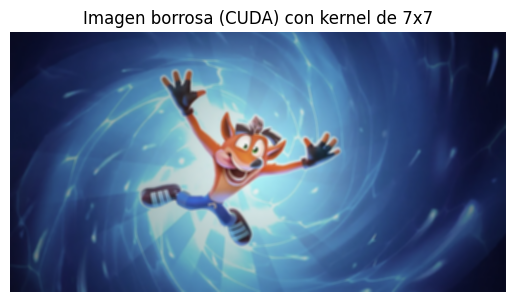

In [19]:
if 'img_color' in locals() and img_color is not None:
    height, width, channels = img_color.shape

    # Aplanar la imagen a una matriz 1D para simplificar el procesamiento del núcleo.
    img_flat = img_color.flatten()

    # Definir el tamaño del núcleo (por ejemplo, 3x3 para un desenfoque medio).
    kernel_size = 7

    # Asignar memoria en la GPU para imágenes de entrada y salida.
    d_input_image = cuda.to_device(img_flat)
    d_output_image = cuda.device_array_like(d_input_image)

    # Definir el número de subprocesos por bloque y bloques por cuadrícula.
    # Cada subproceso procesa un elemento de la matriz aplanada (un canal de un píxel).
    threads_per_block = 256
    blocks_per_grid = (img_flat.size + (threads_per_block - 1)) // threads_per_block

    # Lanzar el kernel de desenfoque CUDA.
    blur_image_kernel[blocks_per_grid, threads_per_block](
        d_input_image, d_output_image, height, width, channels, kernel_size
    )

    # Transferir la imagen borrosa desde la GPU de vuelta a la CPU
    blurred_flat = d_output_image.copy_to_host()

    # Reestructurar la matriz aplanada para que vuelva a tener las dimensiones originales de la imagen (altura, anchura, canales).
    blurred_img_bgr = blurred_flat.reshape(img_color.shape)

    # Convertir BGR a RGB para mostrar con matplotlib
    blurred_img_rgb = cv2.cvtColor(blurred_img_bgr, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen borrosa
    plt.imshow(blurred_img_rgb)
    plt.title(f"Imagen borrosa (CUDA) con kernel de {kernel_size}x{kernel_size}")
    plt.axis('off')
    plt.show()
else:
    print("Asegúrese de que se haya cargado una imagen y de que «img_color» esté disponible antes de aplicar el desenfoque.")


#### **Análisis y Conclusión del Ejercicio 2: Desenfoque por Promedio (Average Blurring)**

**Análisis:**
El segundo ejercicio aborda la implementación de un filtro de desenfoque por promedio utilizando CUDA. El kernel `blur_image_kernel` toma la imagen de entrada, sus dimensiones y un `kernel_size` para definir el tamaño del vecindario. Cada hilo calcula el valor promedio de los píxeles dentro de un vecindario `kernel_size x kernel_size` centrado en el píxel actual. Es crucial que cada hilo determine correctamente las coordenadas del píxel en la imagen original y sus vecinos, asegurándose de no acceder a memoria fuera de los límites de la imagen. La imagen se aplana a 1D, pero el kernel necesita reconstruir las coordenadas 2D (y de canal) para el cálculo del promedio.

**Conclusión:**
Este ejercicio es un buen ejemplo de cómo las operaciones que requieren acceso a vecindarios (como la convolución o el desenfoque) pueden ser paralelizadas en CUDA. Aunque el desenfoque por promedio es más complejo que la inversión de color debido a la dependencia de los píxeles vecinos, la arquitectura de hilos de CUDA permite procesar múltiples píxeles simultáneamente. La gestión de los límites de la imagen dentro del kernel es fundamental para evitar errores y artefactos. La eficiencia de esta operación se vuelve muy evidente en imágenes grandes, donde el cálculo del promedio para cada píxel en la CPU sería computacionalmente costoso, mientras que la GPU puede procesar muchos píxeles y sus vecindarios en paralelo, logrando un rendimiento superior.

### **Ejercicio 3**

En primer lugar, definiremos el kernel CUDA para recortar imágenes. Este kernel tomará los datos de la imagen original, la matriz de la imagen recortada resultante, las dimensiones de la imagen original y los parámetros de recorte (coordenadas iniciales y dimensiones de la región recortada). Cada subproceso calculará el valor de un píxel en la imagen resultante (recortada).

In [20]:
@cuda.jit
def crop_image_kernel(input_image, output_image, original_height, original_width, channels,
                        x_start, y_start, width_crop, height_crop):

    # Calcula el índice lineal global para el hilo actual en la imagen de salida
    idx_out = cuda.grid(1)

    # Verifica si el índice está dentro de los límites de los datos de la imagen de salida
    if idx_out >= output_image.size:
        return

    # Descompone el índice lineal en índices de altura (fila), anchura (columna) y canal para la imagen de salida
    h_out = idx_out // (width_crop * channels)
    w_out = (idx_out // channels) % width_crop
    c = idx_out % channels

    # Calcula las coordenadas correspondientes en la imagen original
    h_in = y_start + h_out
    w_in = x_start + w_out

    # Verifica las condiciones de los límites
    if 0 <= h_in < original_height and 0 <= w_in < original_width:
        # Calcula el índice lineal para el píxel correspondiente en la imagen de entrada aplanada
        idx_in = (h_in * original_width * channels) + (w_in * channels) + c
        output_image[idx_out] = input_image[idx_in]
    else:
        # Si el píxel de salida cae fuera de los límites de la imagen original, lo establece en negro
        output_image[idx_out] = 0


A continuación, prepararemos los datos de la imagen, definiremos los parámetros de recorte, transferiremos los datos a la GPU, ejecutaremos el `crop_image_kernel`, recuperaremos el resultado y mostraremos la imagen recortada. Asegúrese de que la imagen se haya cargado correctamente en el paso inicial.

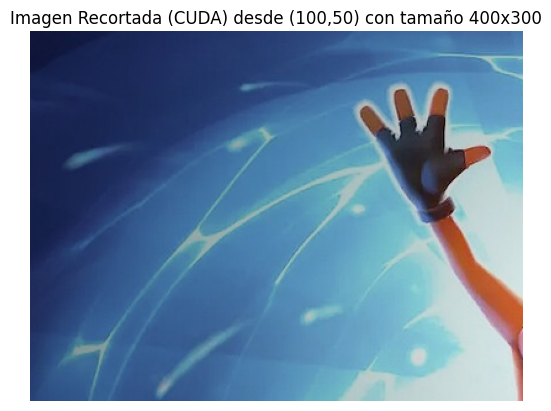

In [21]:
if 'img_color' in locals() and img_color is not None:
    original_height, original_width, channels = img_color.shape

    # Aplanar la imagen original a un arreglo 1D para un procesamiento más sencillo por el kernel
    img_flat = img_color.flatten()

    # Definir los parámetros de recorte (ajustamos estos valores para recortar diferentes regiones)
    x_start = 100  # Coordenada X de inicio (columna)
    y_start = 50   # Coordenada Y de inicio (fila)
    width_crop = 400 # Ancho de la región recortada
    height_crop = 300 # Alto de la región recortada

    # Asegurar que los parámetros de recorte estén dentro de los límites de la imagen original
    # Ajustar width_crop y height_crop si se extienden más allá de la imagen
    if x_start + width_crop > original_width:
        width_crop = original_width - x_start
    if y_start + height_crop > original_height:
        height_crop = original_height - y_start

    # Asegurar que las coordenadas de inicio no estén fuera de los límites
    x_start = max(0, min(x_start, original_width - 1))
    y_start = max(0, min(y_start, original_height - 1))

    # Calcular el tamaño total de la imagen recortada en formato aplanado
    cropped_flat_size = width_crop * height_crop * channels

    # Asignar memoria en el dispositivo (GPU) para las imágenes de entrada y salida
    d_input_image = cuda.to_device(img_flat)
    d_output_image = cuda.device_array(shape=cropped_flat_size, dtype=img_flat.dtype)

    # Definir el número de hilos por bloque y bloques por grilla
    threads_per_block = 256
    blocks_per_grid = (cropped_flat_size + (threads_per_block - 1)) // threads_per_block

    # Lanzar el kernel de recorte CUDA
    crop_image_kernel[blocks_per_grid, threads_per_block](
        d_input_image, d_output_image,
        original_height, original_width, channels,
        x_start, y_start, width_crop, height_crop
    )

    # Transferir la imagen recortada del dispositivo (GPU) de vuelta al host (CPU)
    cropped_flat = d_output_image.copy_to_host()

    # Reformar el arreglo aplanado de nuevo a las dimensiones de la imagen recortada
    cropped_img_bgr = cropped_flat.reshape((height_crop, width_crop, channels))

    # Convertir BGR a RGB para mostrar con matplotlib
    cropped_img_rgb = cv2.cvtColor(cropped_img_bgr, cv2.COLOR_BGR2RGB)

    # Mostrar la imagen recortada
    plt.imshow(cropped_img_rgb)
    plt.title(f"Imagen Recortada (CUDA) desde ({x_start},{y_start}) con tamaño {width_crop}x{height_crop}")
    plt.axis('off')
    plt.show()
else:
    print("Asegúrese de que se haya cargado una imagen y que 'img_color' esté disponible antes de recortar.")


#### **Análisis y Conclusión del Ejercicio 3: Recorte de Imagen (Image Cropping)**

**Análisis:**
El tercer ejercicio implementa una funcionalidad de recorte de imagen utilizando CUDA. El kernel `crop_image_kernel` recibe la imagen original aplanada, las dimensiones originales, y los parámetros de recorte (coordenadas de inicio `x_start`, `y_start` y el tamaño del recorte `width_crop`, `height_crop`). Cada hilo de CUDA calcula la posición de un píxel en la imagen de salida recortada y luego mapea esa posición a la correspondiente en la imagen original de entrada. Si la coordenada mapeada cae dentro de los límites de la imagen original, el valor del píxel se copia; de lo contrario, se establece en negro (0).

**Conclusión:**
El recorte de imagen es otra operación que se beneficia enormemente de la paralelización en la GPU. El kernel demuestra cómo asignar eficientemente los píxeles de una nueva imagen (recortada) a los píxeles de una imagen original más grande, realizando las transformaciones de coordenadas necesarias en cada hilo. La validación de los límites dentro del kernel es esencial para manejar casos donde la región de recorte podría exceder las dimensiones de la imagen original, garantizando la robustez del algoritmo. Este ejercicio subraya la flexibilidad de CUDA para manejar tareas de reorganización de datos y manipulación de regiones de interés con alta eficiencia, lo que es crucial en aplicaciones de visión por computadora que requieren procesamiento rápido de subsecciones de imágenes.

### **Ejercicio 4**

Primero comenzamos creamos una función que permita subir imágenes a cuda

In [25]:
@cuda.jit
def umbral_rgb_kernel(img, salida, T):
    x, y = cuda.grid(2)

    if x < img.shape[0] and y < img.shape[1]:

        r = img[x, y, 2]
        g = img[x, y, 1]
        b = img[x, y, 0]

        promedio = (r + g + b) / 3.0

        # El umbral (T) es el valor límite para decidir si un píxel se convierte en blanco o negro.
        # Si el valor promedio de los canales RGB del píxel es mayor que T,
        # el píxel resultante será blanco (255). De lo contrario, será negro (0).
        if promedio > T:
            salida[x, y] = 255
        else:
            salida[x, y] = 0

In [26]:
if 'img_color' in locals() and img_color is not None:
    # Convertir la imagen a float32 para cálculos precisos en el kernel
    img_cpu_float = img_color.astype(np.float32)

    # Transferir la imagen a la GPU
    img_gpu = cuda.to_device(img_cpu_float)

    alto, ancho, _ = img_color.shape

    # Crear un arreglo en la GPU para almacenar la imagen de salida binaria (uint8)
    salida_gpu = cuda.device_array((alto, ancho), dtype=np.uint8)

    # Umbral
    T = 164.0

    threads_per_block = (16, 16)

    blocks_x = (alto + threads_per_block[0] - 1) // threads_per_block[0]
    blocks_y = (ancho + threads_per_block[1] - 1) // threads_per_block[1]

    blocks_per_grid = (blocks_x, blocks_y)

    # Lanzar el kernel de umbralización
    umbral_rgb_kernel[blocks_per_grid, threads_per_block](img_gpu, salida_gpu, T)

    # Sincronizar y copiar el resultado a la CPU
    cuda.synchronize()
    resultado = salida_gpu.copy_to_host()
else:
    print("Por favor, asegúrese de que la imagen original haya sido cargada en el Ejercicio 1.")

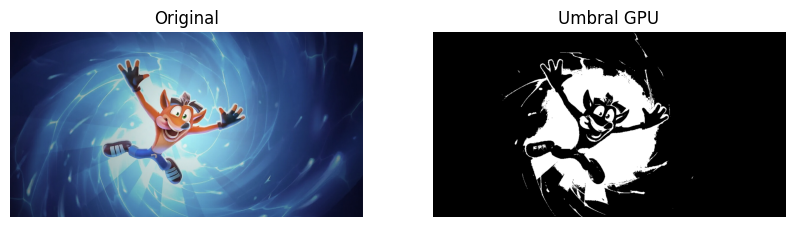

In [27]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
# Usar img_color en lugar de img_cpu para mostrar la imagen original
plt.imshow(cv2.cvtColor(img_color.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resultado, cmap="gray")
plt.title("Umbral GPU")
plt.axis("off")

plt.show()

#### **Análisis y Conclusión del Ejercicio 4: Imagen Binaria (Umbralización)**

**Análisis:**
El cuarto ejercicio se centra en la umbralización para crear una imagen binaria (blanco y negro) usando el kernel CUDA `umbral_rgb_kernel`. Cada hilo de CUDA es responsable de un píxel de la imagen. Para cada píxel, calcula el promedio de sus componentes RGB. Luego, compara este promedio con un umbral `T` predefinido. Si el promedio es mayor que `T`, el píxel de salida se establece en blanco (255); de lo contrario, se establece en negro (0). La imagen se convierte a `float32` antes de transferirla a la GPU para cálculos más precisos del promedio, y la salida se almacena como `uint8`.

**Conclusión:**
Este ejercicio es un excelente ejemplo de cómo la GPU puede ser utilizada para operaciones de clasificación de píxeles en paralelo. La umbralización es fundamental en muchas aplicaciones de visión por computadora para la segmentación de objetos o la extracción de características. La implementación en CUDA permite que todos los píxeles se evalúen simultáneamente, lo que acelera drásticamente el proceso en comparación con las CPU. La capacidad de ajustar el umbral (`T`) ofrece flexibilidad para diferentes condiciones de iluminación o características de la imagen, mostrando la potencia del procesamiento paralelo para aplicar transformaciones basadas en reglas a cada elemento de datos de forma independiente.

### **Ejercicio 5**

In [ ]:
@cuda.jit
def sobel_kernel(input_image, output_image, height, width):

    # Obtener las coordenadas globales del hilo actual en una grilla 2D.
    x, y = cuda.grid(2)

    # Verificar que el hilo esté dentro de los límites válidos de la imagen.
    # Se excluyen los bordes para evitar accesos fuera de rango.
    if x <= 0 or x >= height - 1 or y <= 0 or y >= width - 1:
        return

    # Inicializar acumuladores para los gradientes horizontal (Gx)
    # y vertical (Gy).
    Gx = 0.0
    Gy = 0.0

    # Definición del kernel Sobel en dirección X (detecta bordes verticales).
    Kx = ((-1, 0, 1),
          (-2, 0, 2),
          (-1, 0, 1))

    # Definición del kernel Sobel en dirección Y (detecta bordes horizontales).
    Ky = ((-1, -2, -1),
          ( 0,  0,  0),
          ( 1,  2,  1))

    # Recorrer la vecindad 3x3 alrededor del píxel actual.
    for i in range(3):
        for j in range(3):

            # Calcular coordenadas del vecino respecto al píxel central.
            neighbor_x = x + i - 1
            neighbor_y = y + j - 1

            # Obtener valor del píxel vecino.
            pixel = input_image[neighbor_x, neighbor_y]

            # Acumular contribuciones según los coeficientes del kernel.
            Gx += pixel * Kx[i][j]
            Gy += pixel * Ky[i][j]

    # Calcular la magnitud del gradiente utilizando la norma Euclidiana.
    magnitude = math.sqrt(Gx * Gx + Gy * Gy)

    # Normalizar el valor para mantenerlo dentro del rango [0, 255].
    if magnitude > 255:
        magnitude = 255

    # Asignar el valor final al píxel correspondiente en la imagen de salida.
    output_image[x, y] = int(magnitude)

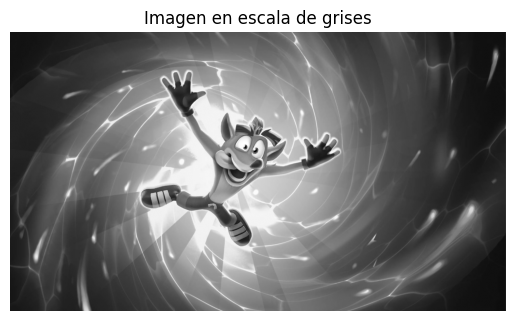

In [ ]:
# Convertir la imagen original a una imagen en escala de grises utilizando la función cvtColor,
#esto reduce la imagen de 3 canales (B, G, R) a un solo canal de intensidad.
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# Asegurar que la imagen esté en formato de 8 bits sin signo.
#Este es el formato estándar para imágenes en escala de grise  y permite valores en el rango [0, 255].
gray = gray.astype(np.uint8)

#Mostrar imagen en escala de grises
plt.imshow(gray, cmap='gray')
plt.title("Imagen en escala de grises")
plt.axis('off')
plt.show()

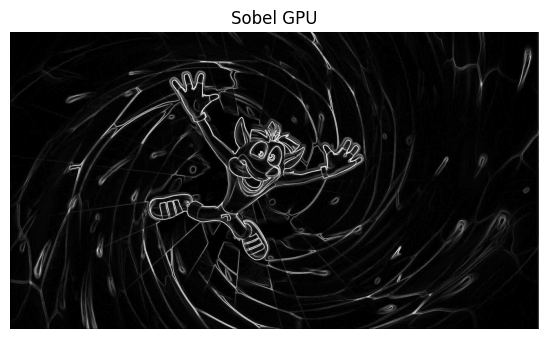

In [ ]:
# Transferir la imagen en escala de grises desde la memoria principal (CPU)  hacia la memoria del dispositivo (GPU).
d_input = cuda.to_device(gray)

# Crear un arreglo en la memoria de la GPU con el mismo tamaño y tipo que la imagen original. Este arreglo almacenará el resultado del filtro Sobel.
d_output = cuda.device_array_like(gray)

# Definir la cantidad de hilos por bloque.
# se utiliza una configuración bidimensional de 16x16 hilos lo que equivale a 256 hilos por bloque.
threads_per_block = (16, 16)

# Calcular el número de bloques necesarios para cubrir completamente la imagen.
blocks_per_grid = (
    math.ceil(gray.shape[0] / 16),
    math.ceil(gray.shape[1] / 16)
)

# Lanzar el kernel Sobel en la GPU.
sobel_kernel[blocks_per_grid, threads_per_block](d_input, d_output)

# Sincronizar el dispositivo para garantizar que la ejecución del kernel
# haya finalizado antes de continuar con el programa.
cuda.synchronize()

# Copiar el resultado desde la memoria de la GPU hacia la memoria del CPU.
result_gpu = d_output.copy_to_host()

# Normalizar la imagen resultado al rango [0, 255] para mejorar la visualización.
result_gpu = cv2.normalize(result_gpu, None, 0, 255, cv2.NORM_MINMAX)

# Convertir nuevamente al tipo uint8 para asegurar compatibilidad
result_gpu = np.uint8(result_gpu)

#Graficar resultado
plt.figure(figsize=(15,7))
plt.subplot(1,2,2)
plt.title("Sobel GPU")
plt.imshow(result_gpu, cmap='gray')
plt.axis("off")
plt.show()

#### **Análisis y Conclusión del Ejercicio 5: Detección de Bordes (Algoritmo Sobel)**

**Análisis:**
El quinto ejercicio implementa el algoritmo de detección de bordes Sobel utilizando un kernel CUDA (`sobel_kernel`). Este kernel opera sobre una imagen en escala de grises. Para cada píxel, calcula los gradientes horizontal (`Gx`) y vertical (`Gy`) aplicando las matrices convolucionales de Sobel correspondientes a un vecindario de 3x3. Luego, la magnitud del gradiente se calcula utilizando la norma Euclidiana (`sqrt(Gx^2 + Gy^2)`). Los píxeles de los bordes se excluyen del procesamiento para evitar accesos fuera de rango. La imagen original se convierte a escala de grises y se transfiere a la GPU, y el resultado se normaliza antes de la visualización.

**Conclusión:**
La detección de bordes Sobel es una operación intensiva en cálculo que se beneficia enormemente de la paralelización de la GPU. Al igual que el desenfoque, requiere acceso a los píxeles vecinos, pero además implica multiplicaciones y sumas más complejas (convolución) para cada píxel. La implementación en CUDA permite que cada hilo calcule el gradiente para un píxel de forma independiente, procesando grandes volúmenes de datos de imagen de manera eficiente. Este ejercicio destaca cómo CUDA puede manejar operaciones de convolución, que son la base de muchos filtros de procesamiento de imágenes y redes neuronales convolucionales (CNNs). La aceleración proporcionada por la GPU es crítica en aplicaciones en tiempo real o en el procesamiento de grandes conjuntos de datos de imágenes, donde la CPU sería considerablemente más lenta.